# Separate the Training and Test Data

In [1]:
import torch
import pickle

In [ ]:
from torch.utils.data import Dataset, random_split

class InstrumentDataset(Dataset):
    def __init__(self, X, y, labels):
        self.X = X
        self.y = y
        self.labels = labels

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        X_i = torch.tensor(self.X[idx].reshape((1, self.X.shape[1], self.X.shape[2])), dtype=torch.float32)
        y_i = torch.tensor(self.y[idx], dtype=torch.long)
        return X_i, y_i

data = pickle.load(open('processed_data.pkl', 'rb'))
X = data["X"]
y = data["y"]
labels_map = data["labels_map"]

num_mfcc = X.shape[1]
num_time_steps = X.shape[2]

generator = torch.Generator().manual_seed(42)
dataset = InstrumentDataset(X=X, y=y, labels=labels_map.keys())    

num_training_points = round(0.8*y.shape[0])
num_validation_points = round(0.2*y.shape[0])
training_dataset, validation_dataset = random_split(dataset, lengths=[num_training_points, num_validation_points], generator=generator)

In [4]:
from torch.utils.data import DataLoader
batch_size = 256
train_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)

In [5]:
for X, y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    print(y)

Shape of X [N, C, H, W]: torch.Size([256, 1, 32, 32])
Shape of y: torch.Size([256]) torch.int64
tensor([ 4,  4,  8,  1,  6, 10,  7, 10, 10, 10,  8, 10, 10, 11,  9,  5, 12, 11,
        10,  2,  8, 10, 10,  0, 10, 11, 10, 10, 10,  1,  7,  0, 13, 10, 11, 10,
        10, 11, 12,  5,  2,  2, 13,  6, 10,  5, 10, 10,  8, 10, 11, 10, 11,  6,
        12,  0, 13,  0,  9,  6, 10, 12,  2,  2, 12,  5, 11,  2, 10, 10,  4,  4,
        12,  6, 10,  6,  6,  0,  9, 10,  2, 11,  9, 11, 10,  2,  8,  5, 11, 13,
         2, 12, 13,  9, 11, 10,  0,  3,  1,  3,  2, 13,  8,  5, 10,  9, 11, 10,
        10, 11,  2,  8,  6, 13, 11, 10,  4,  4,  8, 10,  5, 10,  4,  5, 11,  7,
         5, 10,  5,  5,  9,  6,  2,  7,  8,  5, 13, 10,  0,  5, 11,  1, 10,  9,
        12,  1, 10, 10,  5,  2, 11, 13,  0, 11,  3, 13,  8,  5,  4, 11, 11, 11,
        13,  5,  8,  0, 10,  5,  0, 10,  4,  2,  8,  4, 10,  1, 11, 11,  2, 12,
        10,  5,  6,  0, 13,  8, 12, 10, 13, 13,  9,  5, 10, 10,  3,  4,  5, 11,
        10, 11, 12,  5, 

/tmp/ipykernel_72821/1873154058.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_i = torch.tensor(self.X[idx].reshape((1, self.X.shape[1], self.X.shape[2])), dtype=torch.float32)


In [6]:
from torch import nn

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
import torch.nn.functional as F

# Define model
# class NeuralNetwork(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.conv1 = nn.Conv2d(1, 6, 5)
#         self.pool = nn.MaxPool2d(2, 2)
#         self.conv2 = nn.Conv2d(6, 16, 5)
#         self.fc1 = nn.Linear(16 * 5 * 5, 120)
#         self.fc2 = nn.Linear(120, 84)
#         self.fc3 = nn.Linear(84, len(labels_map.keys()))
#         # self.flatten = nn.Flatten()
#         # self.linear_relu_stack = nn.Sequential(
#         #     # nn.Conv2d(1, 6, 5),
#         #     nn.Linear(num_mfcc*num_time_steps, 512),
#         #     nn.ReLU(),
#         #     nn.Linear(512, 512),
#         #     nn.ReLU(),
#         #     nn.Linear(512, len(labels_map.keys()))
#         # )

#     def forward(self, x):
#         x = self.pool(F.relu(self.conv1(x)))
#         x = self.pool(F.relu(self.conv2(x)))
#         x = torch.flatten(x, 1) # flatten all dimensions except batch
#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
#         x = self.fc3(x)
#         return x
#         # x = self.flatten(x)
#         # logits = self.linear_relu_stack(x)
#         # return logits

import torch
import torch.nn as nn
import torch.nn.functional as F

r_in = 1.0
r_conv = 1.0
r_hidden = 0.52

class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()
        self.dropout0 = nn.Dropout(1-r_in)
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.dropout1 = nn.Dropout(1 - r_conv)
        # self.conv2 = nn.Conv2d(6, 6, 5)
        # self.dropout2 = nn.Dropout(1 - r_hidden)
        self.conv3 = nn.Conv2d(6, 16, 5)
        self.dropout2 = nn.Dropout(1 - r_conv)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.dropout3 = nn.Dropout(1 - r_hidden)
        self.fc2 = nn.Linear(120, 84)
        self.dropout4 = nn.Dropout(1 - r_hidden)
        # self.fc3 = nn.Linear(84, 84)
        # self.dropout5 = nn.Dropout(1 - r_hidden)
        # self.fc4 = nn.Linear(84, 42)
        # self.dropout6 = nn.Dropout(1 - r_hidden)
        self.fc3 = nn.Linear(84, len(labels_map.keys()))

    def forward(self, input):
        x = F.relu(self.conv1(self.dropout0(input)))
        
        # x = F.max_pool2d(x, (2, 2))
        # x = F.relu(self.conv2(x))
        
        x = self.dropout1(x)
        x = F.max_pool2d(x, (2, 2))
        x = F.relu(self.conv3(x))

        x = self.dropout2(x)
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        
        x = self.dropout3(x)
        x = F.relu(self.fc2(x))
        
        x = self.dropout4(x)
        output = self.fc3(x)
        # c1 = F.relu(self.conv1(input))
        # s2 = F.max_pool2d(c1, (2, 2))
        # c3 = F.relu(self.conv2(s2))
        # s4 = F.max_pool2d(c3, 2)
        # s4 = torch.flatten(s4, 1)
        # f5 = F.relu(self.fc1(s4))
        # f6 = F.relu(self.fc2(f5))
        # output = self.fc3(f6)
        return output


net = Net()
print(net)

model = Net().to(device)
print(model)

Using cpu device
Net(
  (dropout0): Dropout(p=0.0, inplace=False)
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (dropout1): Dropout(p=0.0, inplace=False)
  (conv3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (dropout2): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (dropout3): Dropout(p=0.48, inplace=False)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (dropout4): Dropout(p=0.48, inplace=False)
  (fc3): Linear(in_features=84, out_features=14, bias=True)
)
Net(
  (dropout0): Dropout(p=0.0, inplace=False)
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (dropout1): Dropout(p=0.0, inplace=False)
  (conv3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (dropout2): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (dropout3): Dropout(p=0.48, inplace=False)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (dropout4): Dropout(p=0.48

In [7]:
train_dataloader

In [8]:
import torch.optim as optim

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# for epoch in range(2):  # loop over the dataset multiple times

#     running_loss = 0.0
#     for i, data in enumerate(train_dataloader, 0):
#         # get the inputs; data is a list of [inputs, labels]
#         inputs, labels = data

#         # zero the parameter gradients
#         optimizer.zero_grad()

#         # forward + backward + optimize
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()

#         # print statistics
#         running_loss += loss.item()
#         if i % 2000 == 1999:    # print every 2000 mini-batches
#             print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
#             running_loss = 0.0

# print('Finished Training')
import matplotlib.pyplot as plt

loss_fn = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
optimizer = torch.optim.SGD(model.parameters(), lr=5e-3, momentum=0.1)

def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    


def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return 1-correct

train_error = []
test_error = []

In [9]:
epochs = 60000
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test_error.append(test(test_dataloader, model, loss_fn))
print("Done!")

Epoch 1
-------------------------------
loss: 2.657687  [  256/ 2330]


/tmp/ipykernel_72821/1873154058.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_i = torch.tensor(self.X[idx].reshape((1, self.X.shape[1], self.X.shape[2])), dtype=torch.float32)


Test Error: 
 Accuracy: 3.8%, Avg loss: 2.649824 

Epoch 2
-------------------------------
loss: 2.651929  [  256/ 2330]
Test Error: 
 Accuracy: 8.6%, Avg loss: 2.649552 

Epoch 3
-------------------------------
loss: 2.653257  [  256/ 2330]
Test Error: 
 Accuracy: 8.6%, Avg loss: 2.648995 

Epoch 4
-------------------------------
loss: 2.656646  [  256/ 2330]
Test Error: 
 Accuracy: 8.6%, Avg loss: 2.641501 

Epoch 5
-------------------------------
loss: 2.641059  [  256/ 2330]
Test Error: 
 Accuracy: 8.6%, Avg loss: 2.638654 

Epoch 6
-------------------------------
loss: 2.637204  [  256/ 2330]
Test Error: 
 Accuracy: 8.6%, Avg loss: 2.633676 

Epoch 7
-------------------------------
loss: 2.638360  [  256/ 2330]
Test Error: 
 Accuracy: 8.6%, Avg loss: 2.632561 

Epoch 8
-------------------------------
loss: 2.630610  [  256/ 2330]
Test Error: 
 Accuracy: 8.6%, Avg loss: 2.631480 

Epoch 9
-------------------------------
loss: 2.629571  [  256/ 2330]
Test Error: 
 Accuracy: 8.6%, Av

KeyboardInterrupt: 

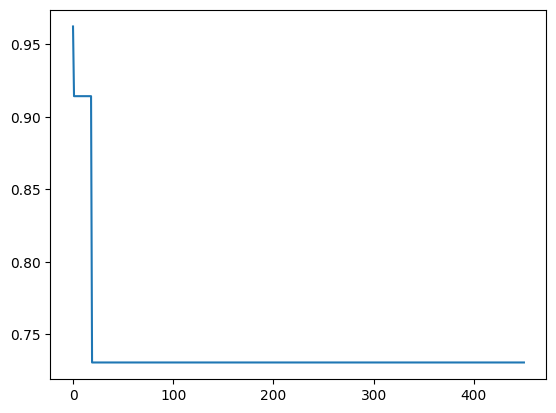

In [11]:
import numpy as np
plt.plot(np.array(test_error))
# plt.ylim([0.0, 0.02])

In [ ]:
map = {v:k for k, v in labels_map.items()}

count = 0
for X, y in train_dataloader:    
    for i in range(len(y)):
        count += 1
        pred = model(X)
        pred_index = torch.argmax(pred[i,:])
        true_index = y[i]

        pred = map[int(pred_index)]
        truth = map[int(true_index)]
        if not pred == truth:
            print(f"{pred} | {truth}")

print(count)

Cello | Contrabass
Viola | Violin
Oboe | Alto Saxophone
Contrabass | Cello
Cello | Alto Saxophone
Clarinet in Bb | Flute
French Horn | Bass Tuba
Flute | Trumpet in C
Clarinet in Bb | Flute
2330


In [ ]:
map = {v:k for k, v in labels_map.items()}

count = 0
for X, y in test_dataloader:    
    for i in range(len(y)):
        count += 1
        pred = model(X)
        pred_index = torch.argmax(pred[i,:])
        true_index = y[i]

        pred = map[int(pred_index)]
        truth = map[int(true_index)]
        if not pred == truth:
            print(f"{pred} | {truth}")

print(count)

Cello | Viola
Cello | Bass Tuba
Violin | Viola
Viola | Accordion
Flute | Bassoon
Clarinet in Bb | Oboe
Alto Saxophone | Flute
Trumpet in C | Flute
Contrabass | Clarinet in Bb
Accordion | Trombone
Flute | Clarinet in Bb
Bass Tuba | French Horn
Viola | Violin
Clarinet in Bb | Flute
Trumpet in C | Alto Saxophone
Alto Saxophone | Clarinet in Bb
Bass Tuba | Bassoon
Flute | Clarinet in Bb
Clarinet in Bb | Flute
French Horn | Trombone
Flute | Cello
Cello | Contrabass
Oboe | Flute
Violin | Accordion
Viola | Violin
Oboe | Alto Saxophone
Trumpet in C | Alto Saxophone
French Horn | Trombone
Viola | Bassoon
Clarinet in Bb | Oboe
Bassoon | French Horn
Accordion | Oboe
583


Feature batch shape: torch.Size([256, 1, 32, 32])
Labels batch shape: torch.Size([256])


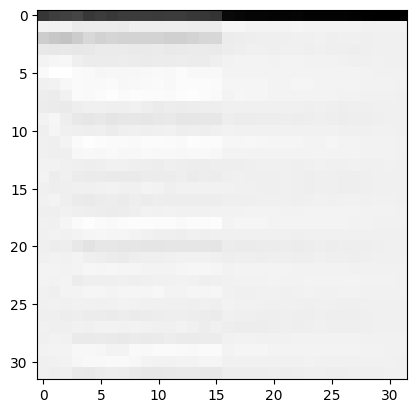

Label: 2


In [ ]:
import matplotlib.pyplot as plt
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[2].squeeze()
label = train_labels[2]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

from torch.utils.data import Dataset

class AudioDataset(DataSet):
    pass

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(20, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.module(x)
    
model = MLP()

learning_rate = 1e-3
batch_size = 64
epochs = 5

# Initialize the loss function
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

NameError: name 'DataSet' is not defined

I got the dataset from kaggle [here](https://www.kaggle.com/datasets/thedevastator/tinysol-isolated-musical-notes-from-14-musical-i).

I decided to reduce the dimensionality of the model for our use case

https://reference.wolfram.com/language/ref/netencoder/Audio.html

Using the tutorial above, I settled on using the AudioMFCC encoder, which has a corresponding function in a Python library

https://docs.pytorch.org/audio/master/generated/torchaudio.transforms.MFCC.html



I couldn't get torchaudio working, so intead I am using a different library
[text](https://python-speech-features.readthedocs.io/en/latest/#)

Here is a pytorch version of dropout
[link](https://codesignal.com/learn/courses/improving-neural-networks-with-pytorch/lessons/adding-dropout-to-neural-networks-in-pytorch)

In [ ]:
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

In [ ]:
from python_speech_features import mfcc
from python_speech_features import logfbank
import scipy.io.wavfile as wav

nfft = 4096

(rate,sig) = wav.read("Brass/Bass_Tuba/ordinario/BTb-ord-A1-ff-N-T19d.wav")
(rate,sig) = wav.read("Brass/Horn/ordinario/Hn-ord-A1-mf-N-N.wav")

mfcc_feat = mfcc(sig,rate, nfft=nfft, winlen=50e-3)
print(mfcc_feat[mfcc_feat.shape[0]//2,:])

nfft = 4096
(rate,sig) = wav.read("Brass/Horn/ordinario/Hn-ord-A1-mf-N-N.wav")
mfcc_feat = mfcc(sig,rate, nfft=nfft, winlen=50e-3 )
# fbank_feat = logfbank(sig,rate, nfft=nfft)

print(mfcc_feat[mfcc_feat.shape[0]//2,:])

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

def plot_mfcc(audio_path, ax, title):
    # Load the audio file
    y, sr = librosa.load(audio_path)

    # Extract MFCC features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20, n_fft=1800)

    # Plot MFCCs
    # plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfccs, x_axis='time', cmap='viridis', ax = ax)
    # ax.colorbar(format='%+2.0f dB')
    ax.set_title(title)
    ax.set_xlabel('Time')
    ax.set_ylabel('MFCC Coefficient')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Example usage
audio_file_path1 = "Winds/Bassoon/ordinario/Bn-ord-D#3-pp-N-N.wav"
# audio_file_path2 = "Brass/Bass_Tuba/ordinario/BTb-ord-D#3-mf-N-T25u.wav"
# audio_file_path1 = "Brass/Horn/ordinario/Hn-ord-A1-mf-N-N.wav"
audio_file_path2 = "Brass/Trombone/ordinario/Tbn-ord-D#3-ff-N-N.wav"
# audio_file_path1 = "Strings/Viola/ordinario/Va-ord-A#3-ff-3c-N.wav"
# audio_file_path2 = "Strings/Viola/ordinario/Va-ord-G5-ff-3c-N.wav"
plot_mfcc(audio_file_path1, ax1, "Basson playing D#3")
plot_mfcc(audio_file_path2, ax2, "Trombone playing D#3")

I found this [tutorial](https://www.geeksforgeeks.org/machine-learning/classification-using-sklearn-multi-layer-perceptron/) helpful


In [ ]:
from sklearn.neural_network import MLPClassifier

MLPClassifier()

This [tutorial](https://www.geeksforgeeks.org/deep-learning/training-neural-networks-with-dropout-for-effective-regularization/)
 goes over training with dropout with tensorflow